# Real-data benchmarking — ASV counts & mapping fidelity vs sequencing depth

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import glob, re, os
import seaborn as sns 

plt.rcParams.update({'font.size': 7})

BASE        = '..'  # Parent directory (run notebook from real_notebook/)
SUB_DIR     = f'{BASE}/results_real/subsampled'
SAVONT_DIR  = f'{BASE}/results_real/savont'
UNOISE_DIR  = f'{BASE}/results_real/unoise'
UNOISE3_DIR = f'{BASE}/results_real/unoise_min3'
MAP_DIR     = f'{BASE}/results_real/map_ont_pb'

SAMPLES   = ['AD1_ont', 'WWTP1_ont', 'Zfecal1_ont', 'Soil1_ont']
NICE_SAMPLES = {'AD1_ont': 'Anaerobic Digester', 'WWTP1_ont': 'Wastewater', 'Zfecal1_ont': 'Fecal', 'Soil1_ont': 'Soil'}
FRACTIONS = [1, 0.33, 0.111, 0.037, 0.012, 0.004]
METHODS   = ['savont', 'unoise', 'unoise_min3']
palette = sns.color_palette('muted')

METHOD_STYLES = {'savont': '-', 'unoise': '--', 'unoise_min3': '-.'}
METHOD_MARKERS = {'savont': 'o', 'unoise': 's', 'unoise_min3': '^'}
METHOD_COLORS = {'savont': palette[0], 'unoise': palette[1], 'unoise_min3': palette[2]}
METHOD_LABELS = {'savont': 'Savont', 'unoise': 'UNOISE3', 'unoise_min3': 'UNOISE3 (min 3 reads)'}

In [3]:
def count_reads(fastq_path):
    """Count reads in a FASTQ file (lines / 4)."""
    if not os.path.exists(fastq_path):
        return np.nan
    with open(fastq_path) as f:
        return sum(1 for _ in f) // 4

def count_asvs(fasta_path):
    """Count sequences in a FASTA file."""
    if not os.path.exists(fasta_path):
        return np.nan
    with open(fasta_path) as f:
        return sum(1 for line in f if line.startswith('>'))

def parse_paf(paf_path):
    """Return (n_mapped, n_perfect, n_mismatch) from a minimap2 PAF file."""
    if not os.path.exists(paf_path) or os.path.getsize(paf_path) == 0:
        return np.nan, np.nan, np.nan
    nm_re = re.compile(r'NM:i:(\d+)')
    n_mapped = n_perfect = n_mismatch = 0
    with open(paf_path) as f:
        for line in f:
            if not line.strip():
                continue
            n_mapped += 1
            m = nm_re.search(line)
            nm = int(m.group(1)) if m else 0
            if nm == 0:
                n_perfect += 1
            else:
                n_mismatch += 1
    return n_mapped, n_perfect, n_mismatch

_depth_re = re.compile(r'_depth_(\d+)')

def get_depths_savont(fasta_path):
    """Parse per-ASV depth from savont FASTA headers (_depth_N)."""
    if not os.path.exists(fasta_path):
        return []
    depths = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith('>'):
                m = _depth_re.search(line)
                if m:
                    depths.append(int(m.group(1)))
    return depths

def get_depths_otutab(otutab_path):
    """Sum counts per OTU row across all columns in a usearch OTU table."""
    if not os.path.exists(otutab_path) or os.path.getsize(otutab_path) == 0:
        return []
    tab = pd.read_csv(otutab_path, sep='\t', index_col=0)
    return tab.sum(axis=1).tolist()

def shannon(depths):
    """Shannon diversity H = -sum(p * log(p)) from a list of per-OTU depths."""
    a = np.array([d for d in depths if d > 0], dtype=float)
    if len(a) == 0:
        return np.nan
    p = a / a.sum()
    return float(-np.sum(p * np.log(p)))

print("helpers defined")

helpers defined


In [4]:
OTUTAB_DIR = f'{BASE}/results_real/otutabs'

rows = []
for sample in SAMPLES:
    for frac in FRACTIONS:
        frac_str = str(frac)
        fastq   = f'{SUB_DIR}/{sample}_frac{frac_str}.fastq'
        n_reads = count_reads(fastq)

        asv_paths = {
            'savont':      f'{SAVONT_DIR}/{sample}_frac{frac_str}/final_asvs.fasta',
            'unoise':      f'{UNOISE_DIR}/{sample}_frac{frac_str}/zotus.fa',
            'unoise_min3': f'{UNOISE3_DIR}/{sample}_frac{frac_str}/zotus.fa',
        }
        for method in METHODS:
            n_asvs = count_asvs(asv_paths[method])
            paf    = f'{MAP_DIR}/{method}/{sample}_frac{frac_str}.map.tsv'
            n_mapped, n_perfect, n_mismatch = parse_paf(paf)

            # per-OTU depths for Shannon diversity
            if method == 'savont':
                depths = get_depths_savont(asv_paths[method])
            else:
                otutab = f'{OTUTAB_DIR}/{method}/{sample}_frac{frac_str}.tsv'
                depths = get_depths_otutab(otutab)
            h = shannon(depths)

            rows.append(dict(
                sample=sample, fraction=frac, method=method,
                n_reads=n_reads, n_asvs=n_asvs,
                n_mapped=n_mapped, n_perfect=n_perfect, n_mismatch=n_mismatch,
                shannon=h,
            ))
    print(f"Processed sample {sample}")

df = pd.DataFrame(rows)
df['frac_mapped']  = df['n_mapped']   / df['n_asvs']
df['frac_perfect'] = df['n_perfect']  / df['n_asvs']
df['frac_mismatch']= df['n_mismatch'] / df['n_asvs']
df['sample_label'] = df['sample'].str.replace('1_ont', '', regex=False)
print(df.shape)
df.head(6)

Processed sample AD1_ont
Processed sample WWTP1_ont
Processed sample Zfecal1_ont
Processed sample Soil1_ont
(72, 13)


,sample,fraction,method,n_reads,n_asvs,n_mapped,n_perfect,n_mismatch,shannon,frac_mapped,frac_perfect,frac_mismatch,sample_label
0,AD1_ont,1.00,savont,1348414,2231,2230.0,1144.0,1086.0,5.445336,0.999552,0.512775,0.486777,AD
1,AD1_ont,1.00,unoise,1348414,110,110.0,107.0,3.0,3.965631,1.000000,0.972727,0.027273,AD
2,AD1_ont,1.00,unoise_min3,1348414,337,337.0,318.0,19.0,4.692296,1.000000,0.943620,0.056380,AD
3,AD1_ont,0.33,savont,443931,1207,1207.0,951.0,256.0,5.234061,1.000000,0.787904,0.212096,AD
4,AD1_ont,0.33,unoise,443931,46,46.0,46.0,0.0,3.356718,1.000000,1.000000,0.000000,AD
5,AD1_ont,0.33,unoise_min3,443931,115,115.0,112.0,3.0,3.994997,1.000000,0.973913,0.026087,AD


In [5]:
# serialize dataframe for reuse



df.to_csv(f'{BASE}/results_real/paf_summary.csv', index=False)

## Plot 1 — ASV count vs sequencing depth (4 panels)

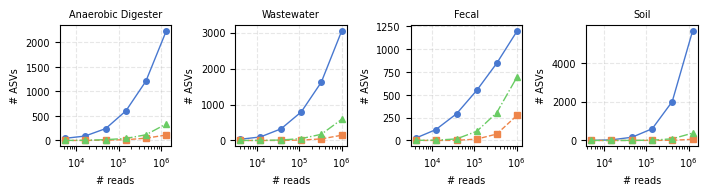

In [6]:
df = pd.read_csv(f'{BASE}/results_real/paf_summary.csv')
fig, axes = plt.subplots(1, 4, figsize=(18/2.54, 5/2.54), sharey=False)

for ax, sample in zip(axes, SAMPLES):
    label = sample.replace('1_ont', '')
    label = NICE_SAMPLES.get(sample, label)
    sub = df[df['sample'] == sample]
    for method in METHODS:
        m = sub[sub['method'] == method].dropna(subset=['n_reads', 'n_asvs'])
        m = m.sort_values('n_reads')
        ax.plot(m['n_reads'], m['n_asvs'],
                color=METHOD_COLORS[method], label=METHOD_LABELS[method], linestyle=METHOD_STYLES[method],
                marker=METHOD_MARKERS[method], markersize=4, linewidth=1)
    ax.set_title(label, fontsize=7)
    ax.set_xlabel('# reads')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylabel('# ASVs')

#axes[0].set_ylabel('# ASVs')
handles = [mlines.Line2D([], [], color=METHOD_COLORS[m], label=METHOD_LABELS[m]) for m in METHODS]
#fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.01),
 #          ncol=3, frameon=False)
plt.tight_layout()
plt.savefig('asv_counts.svg', bbox_inches='tight')
plt.show()

## Plot 2 — Mapping fidelity vs sequencing depth (fractions < 0.25)

count        48.000000
mean      47394.250000
std       50163.381382
min        4038.000000
25%       10322.000000
50%       26563.000000
75%       65252.750000
max      149705.000000
Name: n_reads, dtype: float64


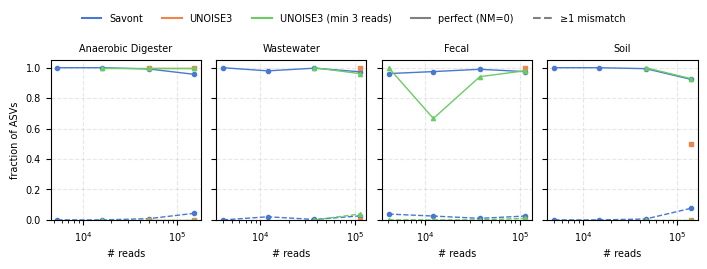

In [7]:
sub025 = df[df['fraction'] < 0.25].copy()

#print # of reads
print(sub025['n_reads'].describe())

fig, axes = plt.subplots(1, 4, figsize=(18/2.54, 6/2.54), sharey=True)

for ax, sample in zip(axes, SAMPLES):
    label = sample.replace('1_ont', '')
    label = NICE_SAMPLES.get(sample, label)
    s = sub025[sub025['sample'] == sample]
    for method in METHODS:
        m = s[s['method'] == method].dropna(subset=['n_reads', 'frac_perfect']).sort_values('n_reads')
        ax.plot(m['n_reads'], m['frac_perfect'],
                color=METHOD_COLORS[method], linewidth=1,
                marker=METHOD_MARKERS[method], markersize=3)
        ax.plot(m['n_reads'], m['frac_mismatch'],
                color=METHOD_COLORS[method], linewidth=1,
                linestyle='--', marker=METHOD_MARKERS[method], markersize=3)
    ax.set_title(label, fontsize=7)
    ax.set_xlabel('# reads')
    ax.set_xscale('log')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')

axes[0].set_ylabel('fraction of ASVs')

# Legend: method colors + line style meaning
method_handles = [mlines.Line2D([], [], color=METHOD_COLORS[m], label=METHOD_LABELS[m]) for m in METHODS]
style_handles  = [
    mlines.Line2D([], [], color='grey', linestyle='-',  label='perfect (NM=0)'),
    mlines.Line2D([], [], color='grey', linestyle='--', label='≥1 mismatch'),
]
fig.legend(handles=method_handles + style_handles,
           loc='upper center', bbox_to_anchor=(0.5, 1.12),
           ncol=5, frameon=False)
plt.tight_layout()
plt.savefig('mapping_fidelity.svg', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1032819/2928158122.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1032819/2928158122.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([meth_labels_small[m] for m in METHODS])


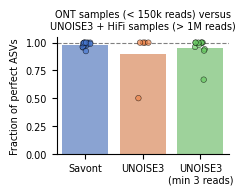

method
savont         0.982296
unoise         0.900000
unoise_min3    0.952541
Name: frac_perfect, dtype: float64
savont: 16 data points
unoise: 5 data points
unoise_min3: 11 data points


In [11]:
import seaborn as sns

sub025 = df[df['fraction'] < 0.25].dropna(subset=['frac_perfect'])

fig, ax = plt.subplots(1,1, figsize=(6/2.54, 5/2.54), sharey=True)
#for sample in SAMPLES:
   # ax = axes[SAMPLES.index(sample)]
p = sns.barplot(
    data=sub025, x='method', y='frac_perfect',
    #order=METHODS,
    hue = 'method',
    hue_order = METHODS,
    palette=METHOD_COLORS,
    errorbar=None,
    capsize=0.1,
    alpha = 0.7,
    legend='brief',
    ax=ax,
)
# labels and legend
sns.stripplot(
    data=sub025, x='method', y='frac_perfect',
    order=METHODS,
    palette=METHOD_COLORS,
    size=4, jitter=True, alpha=0.7,
    edgecolor='black', linewidth=0.4,
    ax=ax,
)
#p.set_xicklabels([])
# remove xticks
#ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Fraction of perfect ASVs')
ax.set_title("ONT samples (< 150k reads) versus\nUNOISE3 + HiFi samples (> 1M reads)", fontsize=7)
sns.despine()
ax.legend_.remove()  # remove legend from individual axes
meth_labels_small = {m: METHOD_LABELS[m] for m in METHODS}
meth_labels_small['unoise_min3'] = 'UNOISE3\n(min 3 reads)'
ax.set_xticklabels([meth_labels_small[m] for m in METHODS])
ax.axhline(1.00, color='grey', linestyle='--', linewidth=0.8)
#ax.legend_.remove()  # remove legend from individual axes
    
    #ax.set_xticks('')

#ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS])
#ax.set_xlabel('')
#ax.set_ylabel('fraction of ASVs mapped perfectly (NM=0)')
#ax.set_ylim(0, 1.05)
#ax.grid(True, axis='y', alpha=0.3, linestyle='--')
#plt.suplegend(handles=method_handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False)
handles, labels = ax.get_legend_handles_labels()
# make legend with nice names
labels = [METHOD_LABELS.get(label, label) for label in labels]
#plt.legend()
#fig.legend(handles, labels, loc='upper center', frameon=False, ncol=3, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('perfect_mapping_barplot.svg', bbox_inches='tight')
#plt.suptitle('ASVs from ONT data with < 150k reads to UNOISE3 + HiFi reference (> 1M reads)', fontsize = 7)
plt.show()

#print mean fraction of perfect ASVs per method
print(sub025.groupby('method')['frac_perfect'].mean())
# print # of datapoints
for method in METHODS:
    print(f"{method}: {len(sub025[sub025['method'] == method])} data points")

## Shannon diversity vs sequencing depth

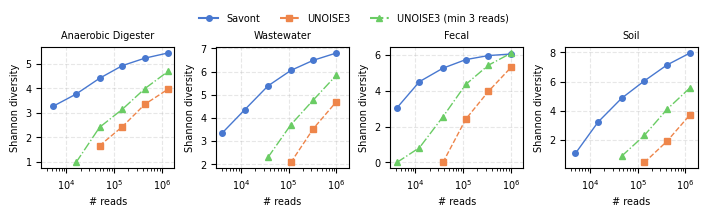

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18/2.54, 5/2.54), sharey=False, sharex=True)

for ax, sample in zip(axes.flatten(), SAMPLES):
    label = NICE_SAMPLES.get(sample, sample.replace('1_ont', ''))
    sub = df[df['sample'] == sample]
    for method in METHODS:
        m = sub[sub['method'] == method].dropna(subset=['n_reads', 'shannon']).sort_values('n_reads')
        ax.plot(m['n_reads'], m['shannon'],
                color=METHOD_COLORS[method], linestyle=METHOD_STYLES[method],
                marker=METHOD_MARKERS[method], markersize=4, linewidth=1,
                label=METHOD_LABELS[method])
    ax.set_title(label, fontsize=7)
    ax.set_xlabel('# reads')
    ax.set_ylabel('Shannon diversity')
    #import matplotlib.ticker as ticker

    #ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3, linestyle='--')

#axes[0].set_ylabel("ASV Shannon diversity")
handles = [mlines.Line2D([], [], color=METHOD_COLORS[m], linestyle=METHOD_STYLES[m],
                         marker=METHOD_MARKERS[m], markersize=4, label=METHOD_LABELS[m])
           for m in METHODS]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=3, frameon=False)
plt.tight_layout()
plt.savefig('shannon_diversity.svg', bbox_inches='tight')
plt.show()